# 01 — Physics Simulation & Dataset Generation

## Background
Non-invasive underground pipe inspection using acoustic sensing works on the same
principle as sonar and medical ultrasound:

1. A short acoustic **pulse** is transmitted into one end of the pipe.
2. Any discontinuity (blockage, foreign object, partial obstruction) reflects part
   of the pulse back toward the transmitter as an **echo**.
3. The **round-trip time** of the echo reveals the blockage position:

$$x_{\text{blockage}} = \frac{t_{\text{echo}} \cdot v}{2}$$

where $v$ is the speed of sound in the pipe medium.

Since real labelled pipe-inspection data is scarce, we build a **physics-based
simulator** to generate unlimited training examples with ground-truth labels.
This is a standard technique in robotics and NDT (Non-Destructive Testing) research.

**This notebook:**
- Explains the simulation model
- Visualises single signals under various conditions
- Generates and saves the training dataset

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from src.simulation import AcousticPipeSimulator, PipeConfig, Blockage, DEFAULT_PIPE

os.makedirs('../outputs/plots',    exist_ok=True)
os.makedirs('../outputs/features', exist_ok=True)
os.makedirs('../data',             exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Setup complete.')

Setup complete.


## 1.1 The Transmitted Pulse
We use a **Gaussian-modulated sine burst** — the same waveform used in real
acoustic transducers. The Gaussian envelope gives a compact, spectrally clean pulse
that minimises ringing artefacts.

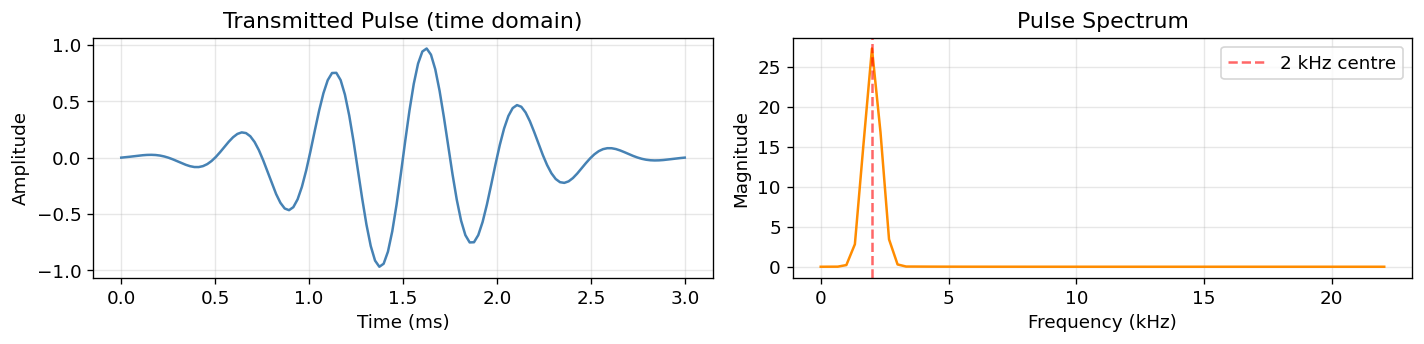

Pulse duration: 3.0 ms  |  Centre freq: 2000 Hz


In [2]:
sim = AcousticPipeSimulator(fs=44_100, pulse_freq=2_000, pulse_duration=0.003)
pulse = sim._pulse
t_pulse = np.linspace(0, sim.pulse_duration * 1000, len(pulse))  # ms

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(t_pulse, pulse, color='steelblue')
axes[0].set(xlabel='Time (ms)', ylabel='Amplitude', title='Transmitted Pulse (time domain)')
axes[0].grid(alpha=0.3)

freqs = np.fft.rfftfreq(len(pulse), d=1/sim.fs)
spectrum = np.abs(np.fft.rfft(pulse))
axes[1].plot(freqs / 1000, spectrum, color='darkorange')
axes[1].set(xlabel='Frequency (kHz)', ylabel='Magnitude', title='Pulse Spectrum')
axes[1].axvline(x=2.0, color='red', linestyle='--', alpha=0.6, label='2 kHz centre')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/01_pulse.png', bbox_inches='tight')
plt.show()
print(f'Pulse duration: {sim.pulse_duration*1000:.1f} ms  |  Centre freq: {sim.pulse_freq} Hz')

## 1.2 Single Blockage — Effect of Position
Below we simulate the same 30 m pipe with a single blockage at three different
positions (10 m, 20 m, 25 m). Notice how the echo arrival time shifts proportionally.

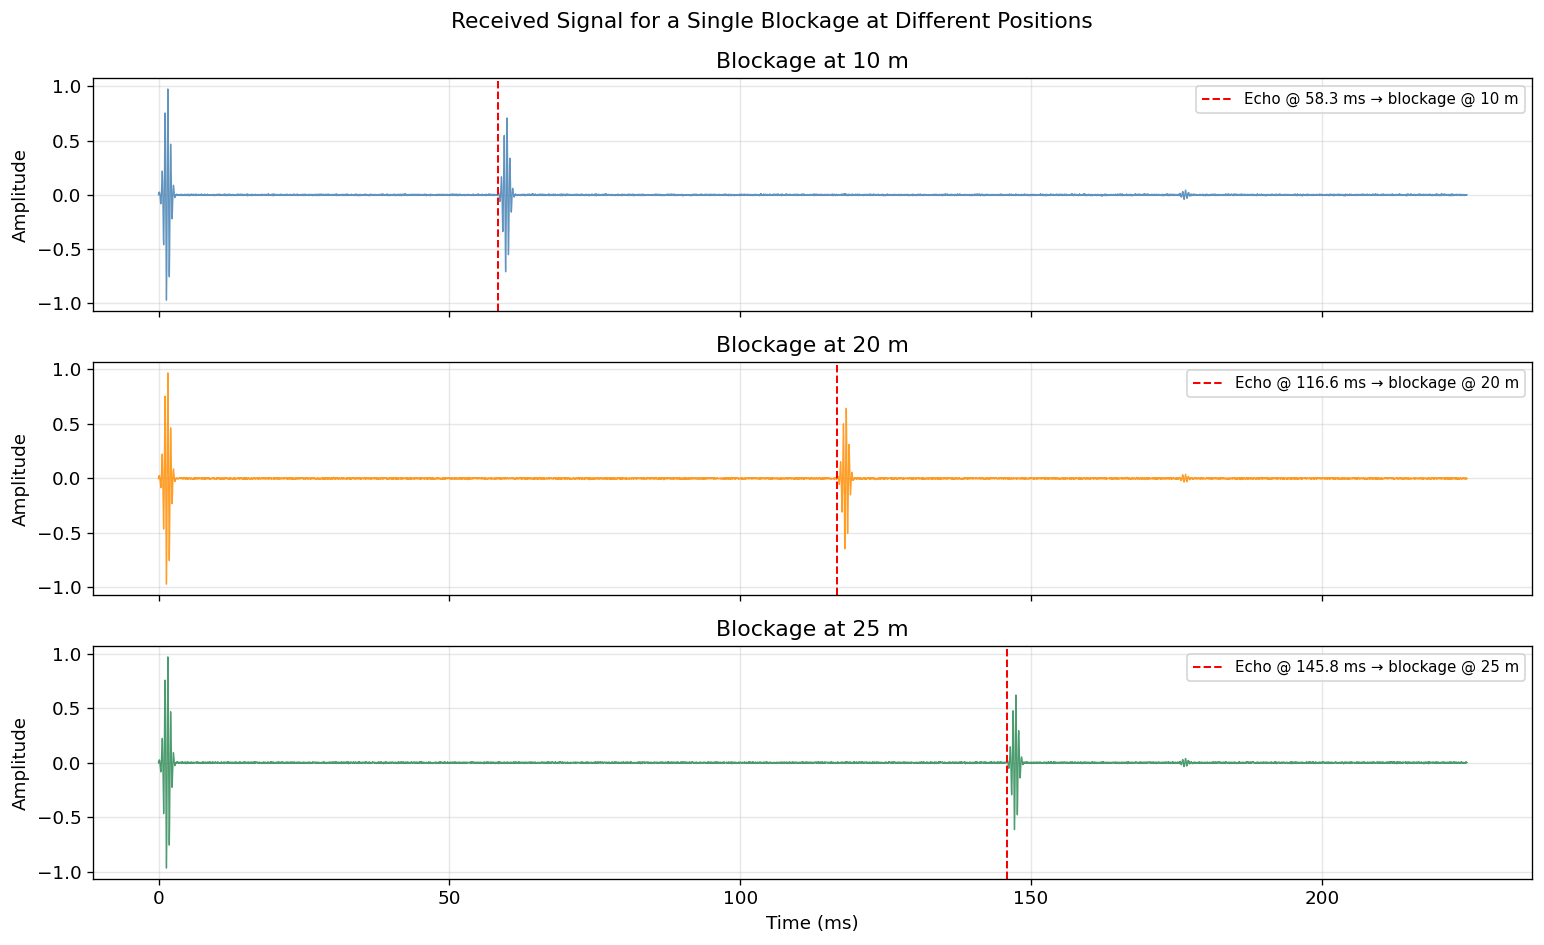

In [3]:
pipe = PipeConfig(length=30.0, speed_of_sound=343.0, attenuation_db_m=0.08)
positions_test = [10.0, 20.0, 25.0]
colors = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

for ax, pos, col in zip(axes, positions_test, colors):
    blockage = [Blockage(position=pos, severity=0.8)]
    t, sig, echo_times = sim.simulate(pipe, blockage, snr_db=25.0)
    ax.plot(t * 1000, sig, color=col, linewidth=0.8, alpha=0.85)
    for et in echo_times:
        ax.axvline(et * 1000, color='red', linestyle='--', linewidth=1.2,
                   label=f'Echo @ {et*1000:.1f} ms → blockage @ {pos:.0f} m')
    ax.set(ylabel='Amplitude', title=f'Blockage at {pos:.0f} m')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time (ms)')
fig.suptitle('Received Signal for a Single Blockage at Different Positions', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/plots/01_single_blockage_positions.png', bbox_inches='tight')
plt.show()

## 1.3 Effect of Blockage Severity
Severity (reflection coefficient) controls echo amplitude. A partial blockage
(0.3) produces a much weaker echo than a full blockage (1.0).

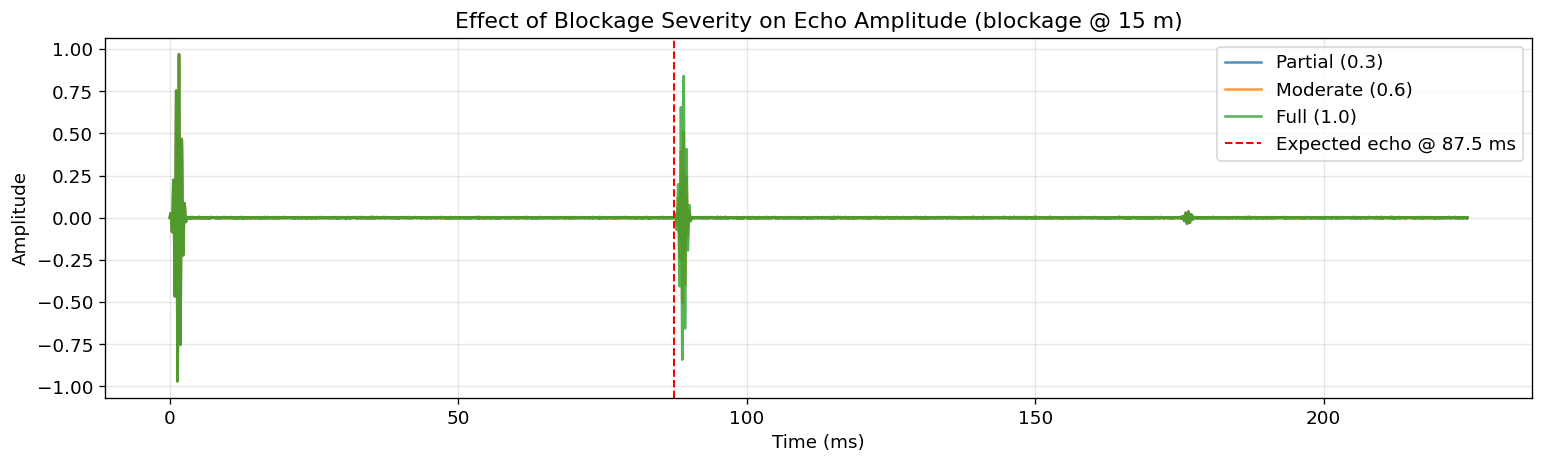

In [4]:
severities = [0.3, 0.6, 1.0]
labels_sev = ['Partial (0.3)', 'Moderate (0.6)', 'Full (1.0)']

fig, ax = plt.subplots(figsize=(13, 4))
for sev, label, col in zip(severities, labels_sev, colors):
    blk = [Blockage(position=15.0, severity=sev)]
    t, sig, _ = sim.simulate(pipe, blk, snr_db=30.0)
    ax.plot(t * 1000, sig, label=label, alpha=0.8)

echo_t = 2 * 15.0 / 343.0 * 1000
ax.axvline(echo_t, color='red', linestyle='--', linewidth=1.2, label=f'Expected echo @ {echo_t:.1f} ms')
ax.set(xlabel='Time (ms)', ylabel='Amplitude',
       title='Effect of Blockage Severity on Echo Amplitude (blockage @ 15 m)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/01_severity_effect.png', bbox_inches='tight')
plt.show()

## 1.4 Clear vs. Blocked Pipe
The most fundamental comparison — a clear pipe (no echo between pulse and end-of-pipe
reflection) versus a blocked pipe (visible intermediate echo).

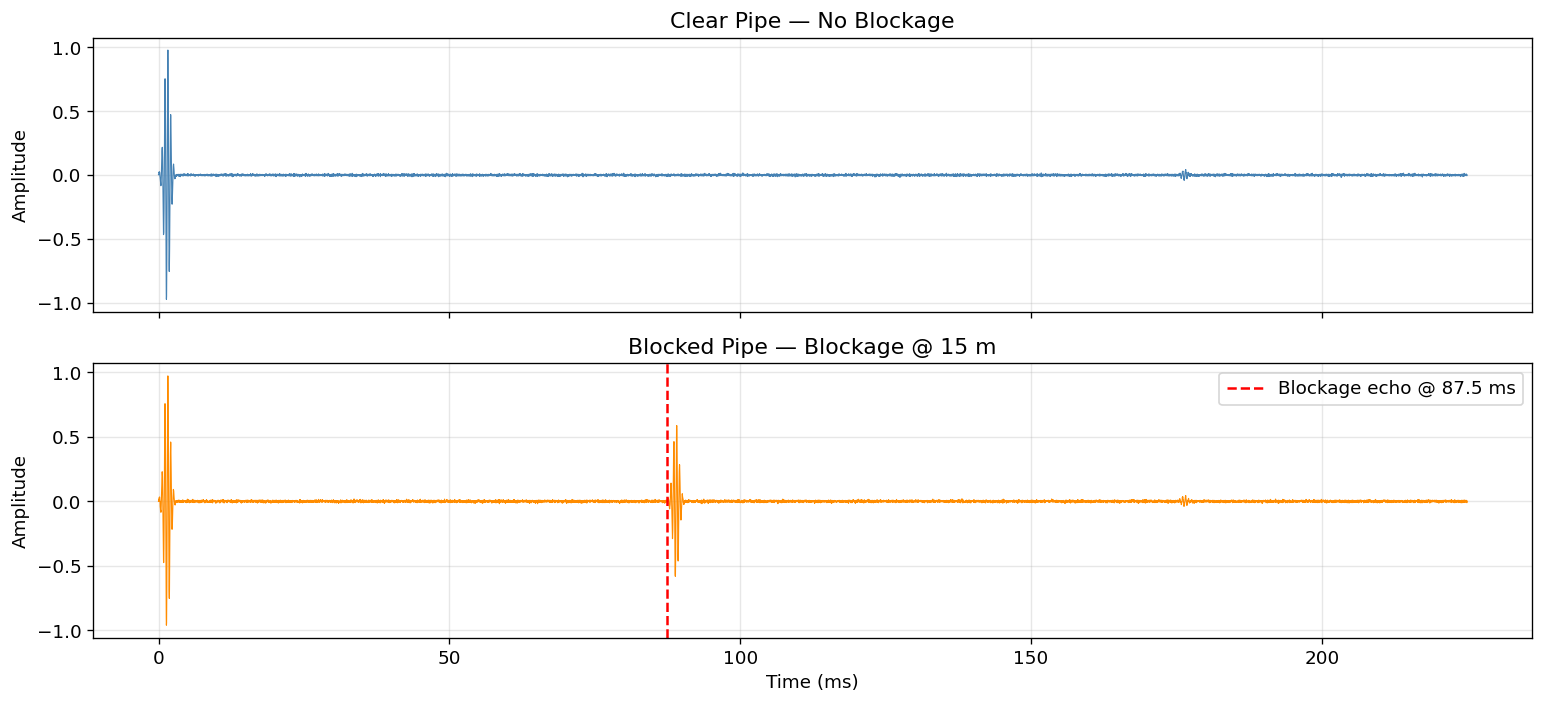

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

# Clear pipe
t, sig_clear, _ = sim.simulate(pipe, [], snr_db=20.0)
axes[0].plot(t * 1000, sig_clear, color='steelblue', linewidth=0.7)
axes[0].set(ylabel='Amplitude', title='Clear Pipe — No Blockage')
axes[0].grid(alpha=0.3)

# Blocked pipe
t, sig_blocked, echo_times = sim.simulate(pipe, [Blockage(15.0, 0.7)], snr_db=20.0)
axes[1].plot(t * 1000, sig_blocked, color='darkorange', linewidth=0.7)
for et in echo_times:
    axes[1].axvline(et * 1000, color='red', linestyle='--', linewidth=1.5,
                    label=f'Blockage echo @ {et*1000:.1f} ms')
axes[1].set(xlabel='Time (ms)', ylabel='Amplitude', title='Blocked Pipe — Blockage @ 15 m')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/01_clear_vs_blocked.png', bbox_inches='tight')
plt.show()

## 1.5 Generate Full Training Dataset

We generate **2,000 labelled signals** with:
- Random pipe lengths: 10–50 m
- 0–3 blockages per pipe, random positions and severities
- Random SNR: 10–30 dB (covers realistic noise conditions)
- Fixed signal duration: 0.35 s (covers even the longest pipe)

All signals are stored as `.npy` files for fast loading in later notebooks.

In [6]:
print('Generating dataset...')
signals, labels, positions = sim.generate_dataset(
    n_samples=2_000,
    pipe_length_range=(10.0, 50.0),
    max_blockages=3,
    snr_range=(10.0, 30.0),
    fixed_duration=0.35,
    seed=42,
)

np.save('../data/signals.npy',   signals)
np.save('../data/labels.npy',    labels)
np.save('../data/positions.npy', positions)

print(f'signals  : {signals.shape}   dtype={signals.dtype}')
print(f'labels   : {labels.shape}    dtype={labels.dtype}')
print(f'positions: {positions.shape}  dtype={positions.dtype}')
print(f'\nClass distribution:')
print(f'  Clear pipes   : {(labels==0).sum()} ({(labels==0).mean()*100:.1f}%)')
print(f'  Blocked pipes : {(labels==1).sum()} ({(labels==1).mean()*100:.1f}%)')

Generating dataset...


signals  : (2000, 15434)   dtype=float32
labels   : (2000,)    dtype=int64
positions: (2000, 3)  dtype=float32

Class distribution:
  Clear pipes   : 490 (24.5%)
  Blocked pipes : 1510 (75.5%)


## 1.6 Dataset Sample Visualisation

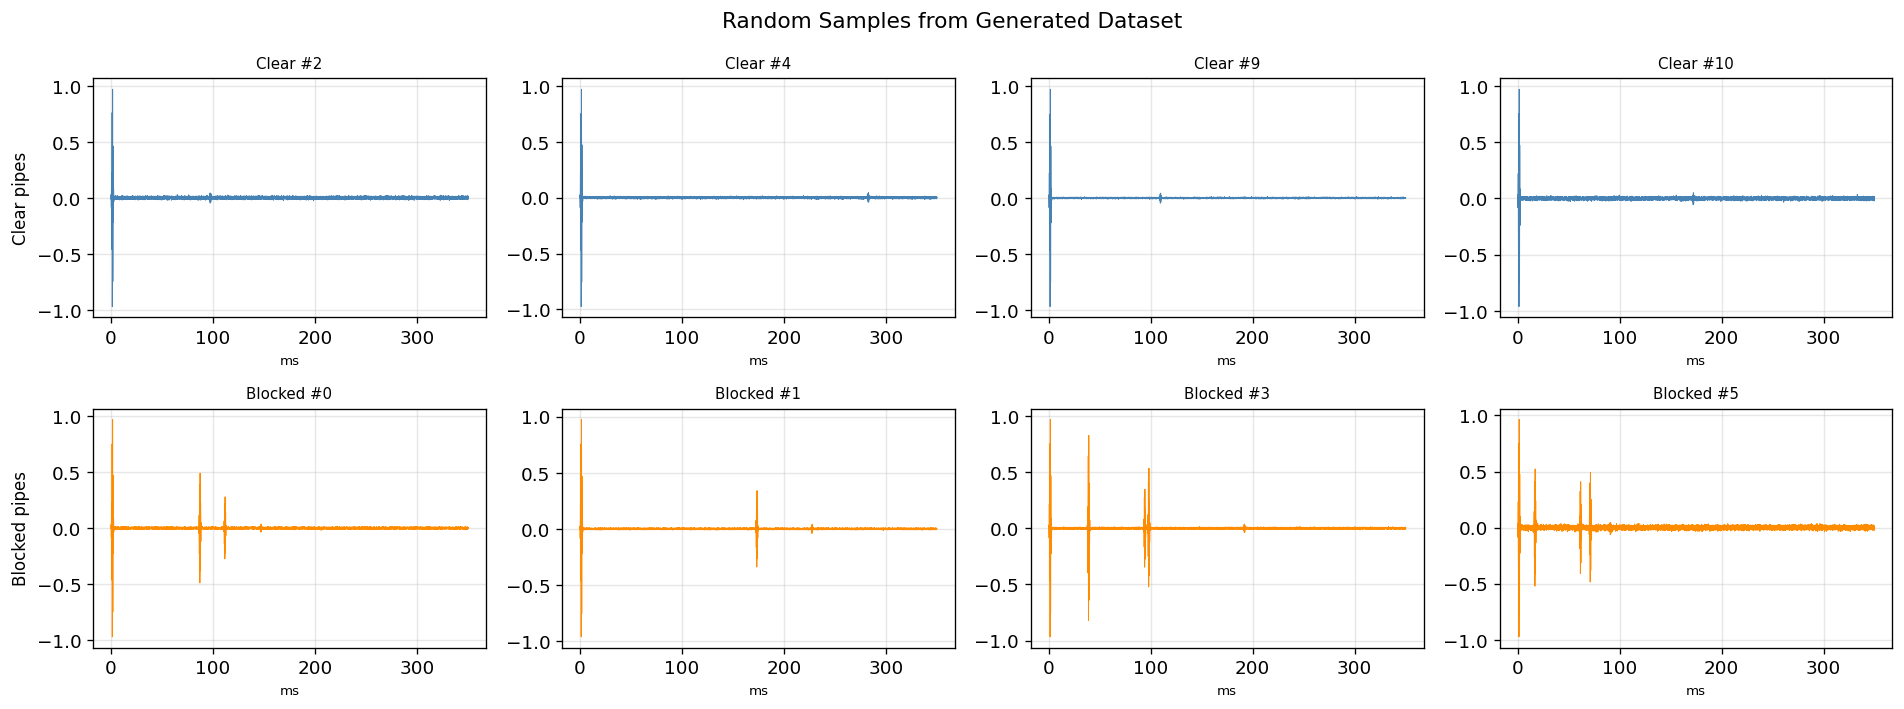

Dataset saved to ../data/


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
t_axis = np.linspace(0, 0.35, signals.shape[1]) * 1000  # ms

# 4 clear, 4 blocked
clear_idx   = np.where(labels == 0)[0][:4]
blocked_idx = np.where(labels == 1)[0][:4]

for col, idx in enumerate(clear_idx):
    axes[0, col].plot(t_axis, signals[idx], linewidth=0.6, color='steelblue')
    axes[0, col].set_title(f'Clear #{idx}', fontsize=9)
    axes[0, col].grid(alpha=0.3)

for col, idx in enumerate(blocked_idx):
    axes[1, col].plot(t_axis, signals[idx], linewidth=0.6, color='darkorange')
    axes[1, col].set_title(f'Blocked #{idx}', fontsize=9)
    axes[1, col].grid(alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('ms', fontsize=8)

axes[0, 0].set_ylabel('Clear pipes', fontsize=10)
axes[1, 0].set_ylabel('Blocked pipes', fontsize=10)
fig.suptitle('Random Samples from Generated Dataset', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/plots/01_dataset_samples.png', bbox_inches='tight')
plt.show()
print('Dataset saved to ../data/')